<a href="https://colab.research.google.com/github/meytriangg/Data-Mining-Course/blob/main/Mey_Analysis_of_Smartphone_Usage_Patterns_for_Predicting_Daily_Productivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Mey Tri Anggraheni 2304020067



# **Analysis of Smartphone Usage Patterns for Predicting Daily Productivity**

This study focuses on analyzing smartphone usage patterns to predict daily productivity levels. The dataset consists of information collected from 1000 users, including variables such as screen time, application usage, sleep duration, number of notifications, and productivity scores.


# **Preprocessing Data**

Before applying classification techniques, the dataset must be prepared through preprocessing steps to handle missing values, transform categorical variables, and normalize numerical features. After that, classification methods can be used to predict whether a user is productive or not based on their smartphone usage behavior.

Import data-load data-data understanding

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/mobile_usage_behavioral_analysis.csv')
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   object 
 3   Total_App_Usage_Hours         1000 non-null   float64
 4   Daily_Screen_Time_Hours       1000 non-null   float64
 5   Number_of_Apps_Used           1000 non-null   int64  
 6   Social_Media_Usage_Hours      1000 non-null   float64
 7   Productivity_App_Usage_Hours  1000 non-null   float64
 8   Gaming_App_Usage_Hours        1000 non-null   float64
 9   Location                      1000 non-null   object 
dtypes: float64(5), int64(3), object(2)
memory usage: 78.3+ KB


,0
User_ID,0
Age,0
Gender,0
Total_App_Usage_Hours,0
Daily_Screen_Time_Hours,0
Number_of_Apps_Used,0
Social_Media_Usage_Hours,0
Productivity_App_Usage_Hours,0
Gaming_App_Usage_Hours,0
Location,0


Data Cleaning (Handle Missing Value & Remove Duplicates)

In [24]:
df.fillna(df.mean(numeric_only=True), inplace=True)

# OUTPUT CHECK
df.isnull().sum()
df.drop_duplicates(inplace=True)

# OUTPUT CHECK
print("Remaining rows:", len(df))

Remaining rows: 1000


Data Transformastion (Encoding Categorical Data)

In [25]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

# OUTPUT CHECK
df.head()

,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location,total_usage
0,0.000000,0.926829,1,0.146764,0.472671,0.807692,0.887776,0.110,0.478958,2,0.311292
1,0.001001,0.682927,1,0.103008,0.983834,0.576923,0.935872,0.884,0.484970,0,0.575784
2,0.002002,0.341463,0,0.572470,0.268668,0.307692,0.917836,0.342,0.565130,1,0.398025
3,0.003003,0.170732,0,0.018232,0.406467,0.692308,0.637275,0.684,0.915832,4,0.213826
4,0.004004,0.487805,1,0.484047,0.891455,0.423077,0.631263,0.026,0.799599,3,0.703736


Normalization

In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# OUTPUT CHECK
df.describe()

,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location,total_usage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.500000,0.505976,0.517000,0.492768,0.514727,0.524885,0.492251,0.499054,0.494070,2.076000,0.497723
std,0.289109,0.297237,0.499961,0.285766,0.285927,0.293062,0.288482,0.288678,0.290654,1.408619,0.208989
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.243902,0.000000,0.236098,0.270978,0.269231,0.240481,0.256500,0.242485,1.000000,0.358094
50%,0.500000,0.536585,1.000000,0.497265,0.528868,0.538462,0.489980,0.487000,0.489980,2.000000,0.501288
75%,0.750000,0.780488,1.000000,0.740428,0.762125,0.769231,0.735972,0.742000,0.756012,3.000000,0.643302
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Discretization

In [30]:
target_column = 'Productivity_App_Usage_Hours'

# Ensure the target column is numeric
df[target_column] = pd.to_numeric(df[target_column], errors='coerce')

# Drop rows where the target column might have become NaN due to coercion
df.dropna(subset=[target_column], inplace=True)

# Discretize the target column into productivity levels
df['productivity_level'] = pd.qcut(
    df[target_column],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# OUTPUT CHECK
df['productivity_level'].value_counts()

,count
productivity_level,
High,334
Low,333
Medium,333


Handle Outliers (Remove Unrealistic Values)

In [31]:
# contoh (sesuaikan nama kolom)
if 'Screen Time' in df.columns:
    df = df[df['Screen Time'] <= 24]

# OUTPUT CHECK
df.describe()

,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location,total_usage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.500000,0.505976,0.517000,0.492768,0.514727,0.524885,0.492251,0.499054,0.494070,2.076000,0.497723
std,0.289109,0.297237,0.499961,0.285766,0.285927,0.293062,0.288482,0.288678,0.290654,1.408619,0.208989
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.243902,0.000000,0.236098,0.270978,0.269231,0.240481,0.256500,0.242485,1.000000,0.358094
50%,0.500000,0.536585,1.000000,0.497265,0.528868,0.538462,0.489980,0.487000,0.489980,2.000000,0.501288
75%,0.750000,0.780488,1.000000,0.740428,0.762125,0.769231,0.735972,0.742000,0.756012,3.000000,0.643302
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


Final Data Check

In [32]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   User_ID                       1000 non-null   float64 
 1   Age                           1000 non-null   float64 
 2   Gender                        1000 non-null   int8    
 3   Total_App_Usage_Hours         1000 non-null   float64 
 4   Daily_Screen_Time_Hours       1000 non-null   float64 
 5   Number_of_Apps_Used           1000 non-null   float64 
 6   Social_Media_Usage_Hours      1000 non-null   float64 
 7   Productivity_App_Usage_Hours  1000 non-null   float64 
 8   Gaming_App_Usage_Hours        1000 non-null   float64 
 9   Location                      1000 non-null   int8    
 10  total_usage                   1000 non-null   float64 
 11  productivity_level            1000 non-null   category
dtypes: category(1), float64(9), int8(2)
memory usage:

# **Classification**

Classification is used to predict users’ daily productivity levels based on their smartphone usage patterns. After the data has been preprocessed, a Decision Tree algorithm is applied to classify users into categories such as low, medium, and high productivity. This approach allows the model to learn patterns from features like screen time, app usage, and sleep duration, and then make predictions on unseen data. The performance of the model is evaluated using accuracy and classification metrics to assess how well it can generalize and correctly classify productivity levels.

=== DATA SHAPE ===
Features: (1000, 11)

Target Distribution:
 productivity_level
High      334
Low       333
Medium    333
Name: count, dtype: int64

=== TRAIN TEST SPLIT ===
Train: (800, 11)
Test: (200, 11)

=== SAMPLE PREDICTIONS ===
['High' 'High' 'Low' 'Medium' 'Low' 'Low' 'Low' 'Medium' 'High' 'High']

=== MODEL PERFORMANCE ===
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        74
      Medium       1.00      1.00      1.00        53

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



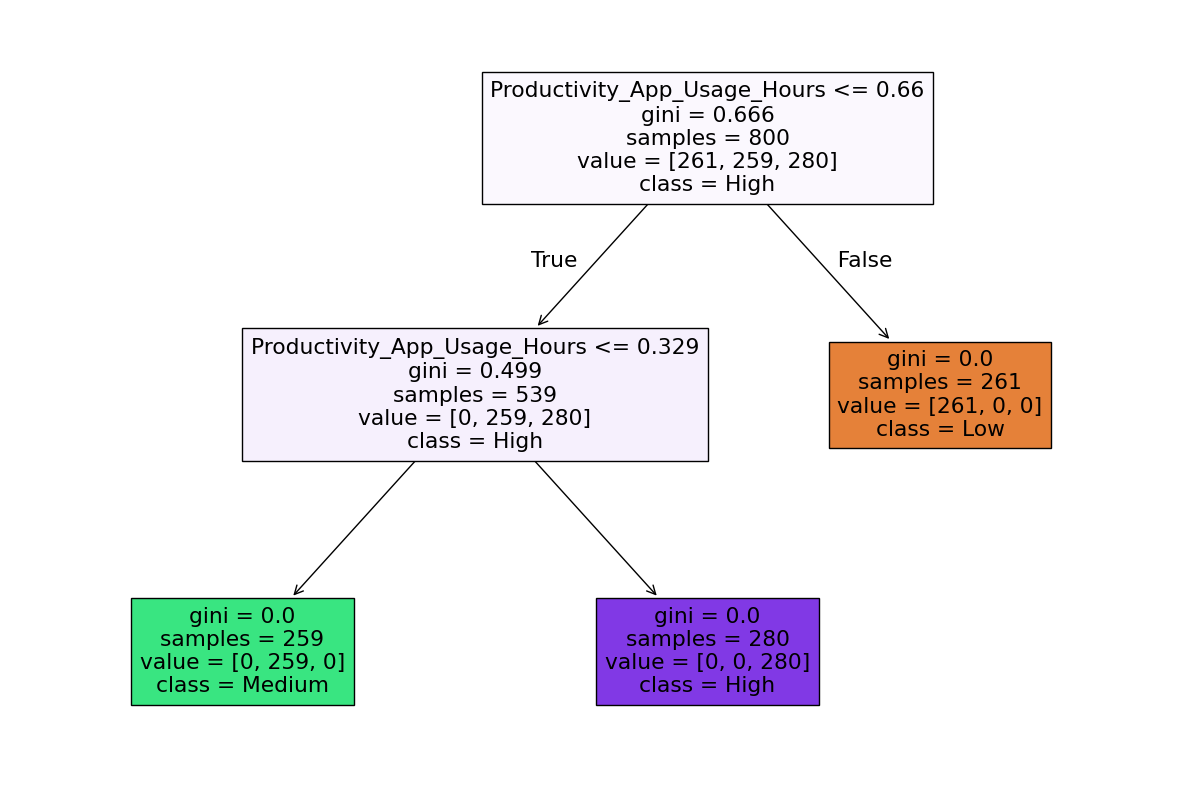

In [42]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# ==============================
# 2. PREPARE DATA
# ==============================
# pastikan kolom ini sudah ada dari preprocessing
target_col = 'productivity_level'

X = df.drop(target_col, axis=1)
y = df[target_col]

print("=== DATA SHAPE ===")
print("Features:", X.shape)
print("\nTarget Distribution:\n", y.value_counts())

# ==============================
# 3. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n=== TRAIN TEST SPLIT ===")
print("Train:", X_train.shape)
print("Test:", X_test.shape)

# ==============================
# 4. TRAIN MODEL (DECISION TREE)
# ==============================
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# ==============================
# 5. PREDICTION
# ==============================
y_pred = model.predict(X_test)

print("\n=== SAMPLE PREDICTIONS ===")
print(y_pred[:10])

# ==============================
# 6. EVALUATION
# ==============================
print("\n=== MODEL PERFORMANCE ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==============================
# 7. VISUALIZATION
# ==============================
plt.figure(figsize=(15,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['Low','Medium','High'])
plt.show()

    User_ID       Age  Gender  Total_App_Usage_Hours  Daily_Screen_Time_Hours  \
0  0.000000  0.926829       1               0.146764                 0.472671   
1  0.001001  0.682927       1               0.103008                 0.983834   
2  0.002002  0.341463       0               0.572470                 0.268668   
3  0.003003  0.170732       0               0.018232                 0.406467   
4  0.004004  0.487805       1               0.484047                 0.891455   

   Number_of_Apps_Used  Social_Media_Usage_Hours  \
0             0.807692                  0.887776   
1             0.576923                  0.935872   
2             0.307692                  0.917836   
3             0.692308                  0.637275   
4             0.423077                  0.631263   

   Productivity_App_Usage_Hours  Gaming_App_Usage_Hours  Location  \
0                         0.110                0.478958         2   
1                         0.884                0.484970       

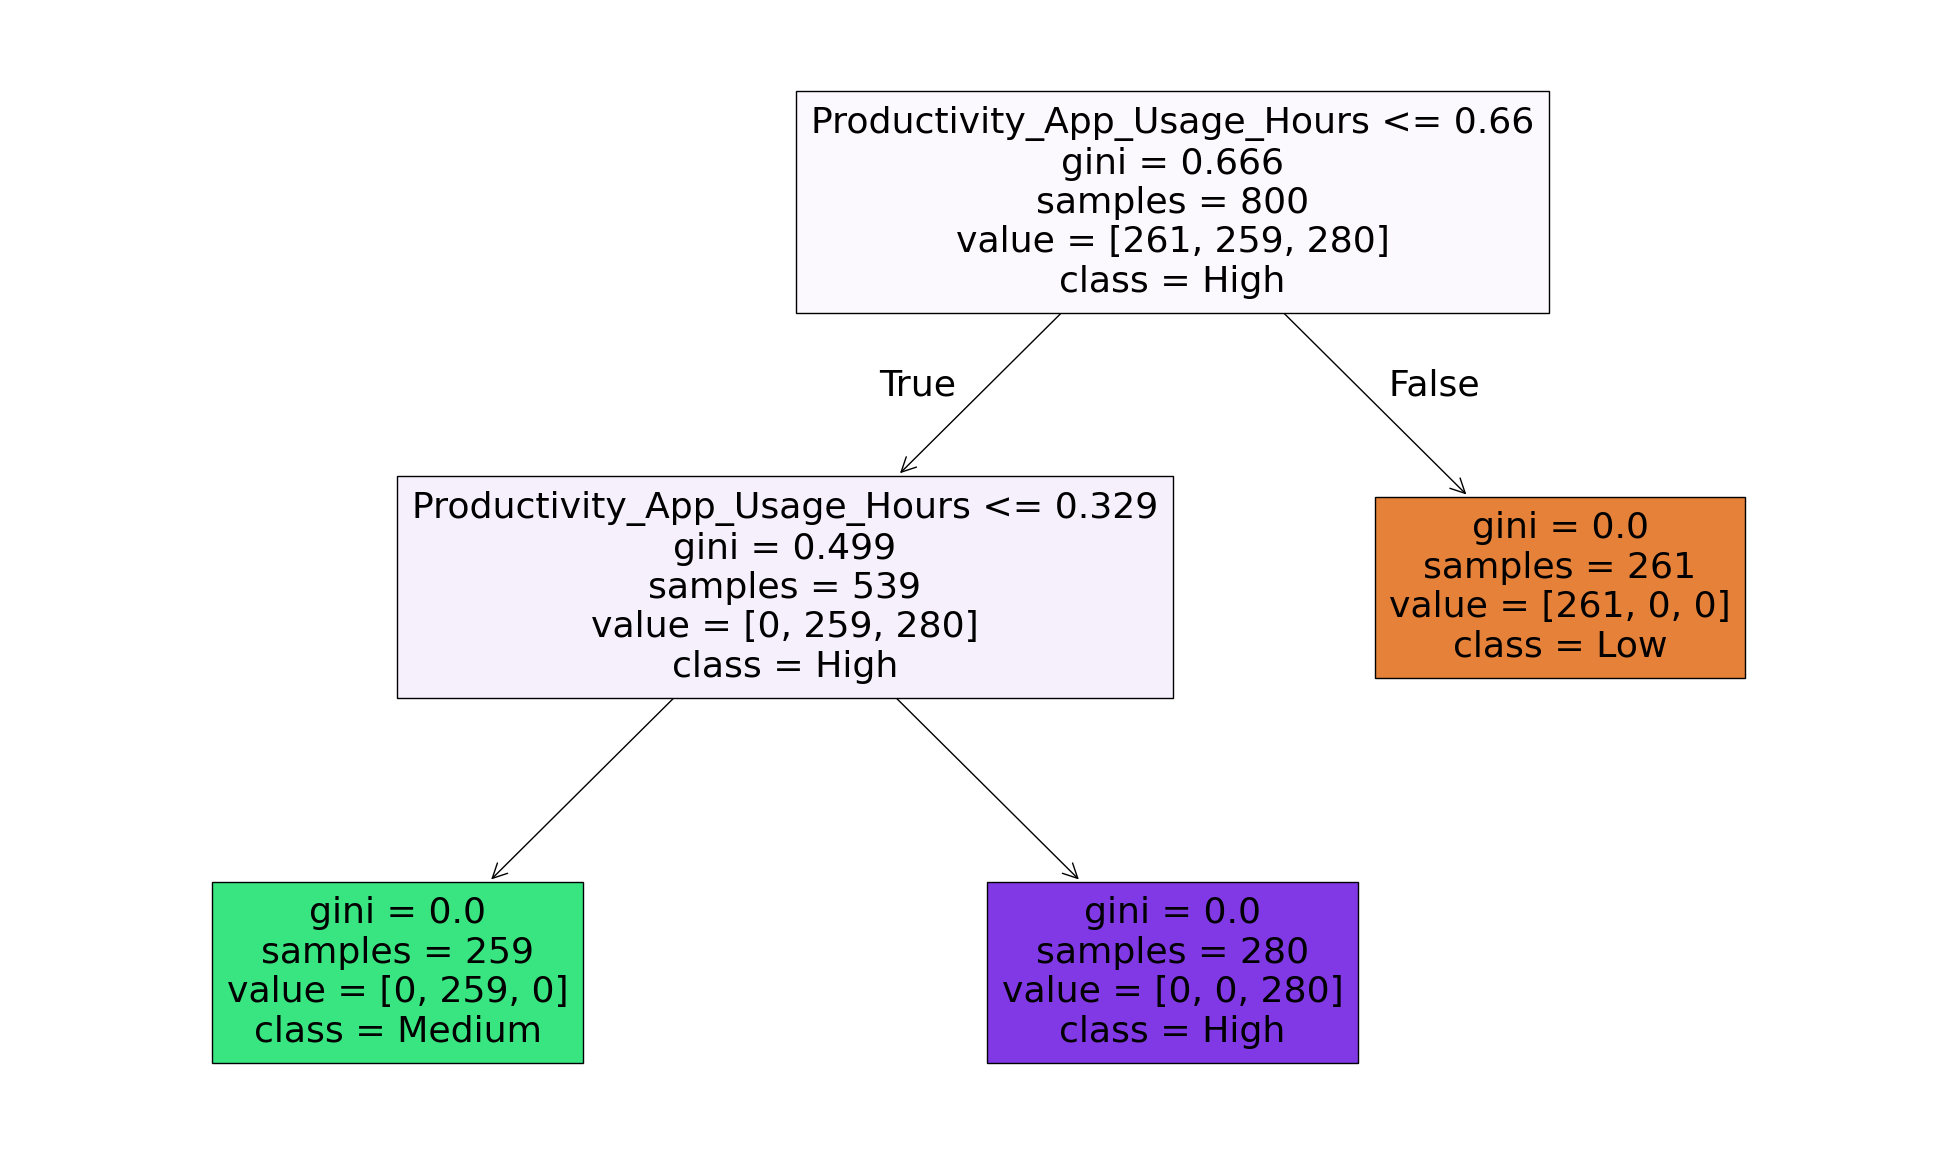

In [41]:
# ==============================
# DECISION TREE (DEEP & COMPLEX)
# ==============================

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# ==============================
# PREPARE DATA
# ==============================
target_col = 'productivity_level'

X = df.drop(target_col, axis=1)
y = df[target_col]

# ==============================
# SPLIT DATA
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
if 'Screen Time' in df.columns and 'Sleep Hours' in df.columns:
    df['usage_ratio'] = df['Screen Time'] / (df['Sleep Hours'] + 1)

if 'Screen Time' in df.columns:
    df['high_screen'] = (df['Screen Time'] > df['Screen Time'].mean()).astype(int)

if 'Sleep Hours' in df.columns:
    df['low_sleep'] = (df['Sleep Hours'] < df['Sleep Hours'].mean()).astype(int)

if 'Notifications' in df.columns:
    df['high_notif'] = (df['Notifications'] > df['Notifications'].mean()).astype(int)

print(df.head())

model.fit(X_train, y_train)

# ==============================
# PREDICTION & EVALUATION
# ==============================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==============================
# INFO POHON (BIAR KEREN 😏)
# ==============================
print("\nTree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())

# ==============================
# VISUALIZATION (RAMAI BANGET)
# ==============================
plt.figure(figsize=(25,15))
plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['Low','Medium','High']
)
plt.show()

In [38]:
if 'Screen Time' in df.columns and 'Sleep Hours' in df.columns:
    df['usage_ratio'] = df['Screen Time'] / (df['Sleep Hours'] + 1)

if 'Screen Time' in df.columns:
    df['high_screen'] = (df['Screen Time'] > df['Screen Time'].mean()).astype(int)

if 'Sleep Hours' in df.columns:
    df['low_sleep'] = (df['Sleep Hours'] < df['Sleep Hours'].mean()).astype(int)

if 'Notifications' in df.columns:
    df['high_notif'] = (df['Notifications'] > df['Notifications'].mean()).astype(int)

print(df.head())

    User_ID       Age  Gender  Total_App_Usage_Hours  Daily_Screen_Time_Hours  \
0  0.000000  0.926829       1               0.146764                 0.472671   
1  0.001001  0.682927       1               0.103008                 0.983834   
2  0.002002  0.341463       0               0.572470                 0.268668   
3  0.003003  0.170732       0               0.018232                 0.406467   
4  0.004004  0.487805       1               0.484047                 0.891455   

   Number_of_Apps_Used  Social_Media_Usage_Hours  \
0             0.807692                  0.887776   
1             0.576923                  0.935872   
2             0.307692                  0.917836   
3             0.692308                  0.637275   
4             0.423077                  0.631263   

   Productivity_App_Usage_Hours  Gaming_App_Usage_Hours  Location  \
0                         0.110                0.478958         2   
1                         0.884                0.484970       